# Fig. S23 | Persistence and river setting

Reads the local-response summaries from experiment 5 and plots river-distance and streambed-connectivity associations.

In [1]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd

ROOT = next(p.resolve() for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'management').is_dir())
DATA = ROOT / 'outputs' / 'MANAGEMENT_2012_2013' / 'local_response'
OUT = ROOT / 'outputs' / 'figures' / 'FigS23' / 'FigS23.png'
OUT.parent.mkdir(parents=True, exist_ok=True)
cells = pd.read_csv(DATA / 'river_persistence_cells.csv.gz')
trends = pd.read_csv(DATA / 'river_persistence_trends.csv')
model = pd.read_csv(DATA / 'river_persistence_model.csv')
P = 'own_unit_persistence_fraction'
DIST = 'distance_to_order12_river_km'
VIC = 'streambed_vic_s'
mpl.rcParams.update({'font.family':'Arial','font.size':10.5,'axes.labelsize':12.5,'axes.titlesize':12.5,'xtick.labelsize':10.5,'ytick.labelsize':10.5,'axes.linewidth':0.7})

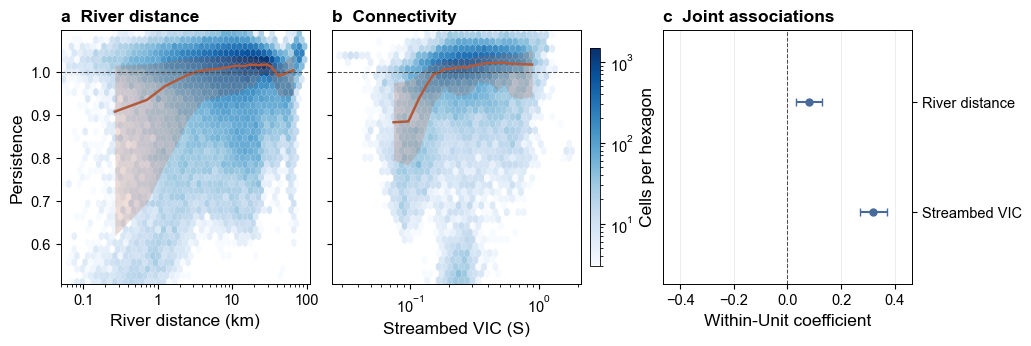

In [2]:
valid = cells[np.isfinite(cells[P])]
streambed = valid[np.isfinite(valid[VIC])]
limits = np.quantile(valid[P], [0.005, 0.995])
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.35), layout='constrained')
density = LogNorm(vmin=3, vmax=1500)
trend_color = '#B45A3C'
hb = axes[0].hexbin(valid[DIST] + 0.05, valid[P], gridsize=45, xscale='log', mincnt=3, cmap='Blues', norm=density, linewidths=0, rasterized=True)
distance = trends[trends.predictor == DIST]
axes[0].fill_between(distance.x + 0.05, distance.q25, distance.q75, color=trend_color, alpha=0.20, lw=0)
axes[0].plot(distance.x + 0.05, distance['median'], color=trend_color, lw=1.8)
axes[0].set(xlabel='River distance (km)', ylabel='Persistence', title='a  River distance', xlim=(0.05,110), ylim=limits)
axes[0].set_xticks([0.1,1,10,100], ['0.1','1','10','100'])
hb = axes[1].hexbin(streambed[VIC], streambed[P], gridsize=42, xscale='log', mincnt=3, cmap='Blues', norm=density, linewidths=0, rasterized=True)
vic = trends[trends.predictor == VIC]
axes[1].fill_between(vic.x, vic.q25, vic.q75, color=trend_color, alpha=0.20, lw=0)
axes[1].plot(vic.x, vic['median'], color=trend_color, lw=1.8)
axes[1].set(xlabel='Streambed VIC (S)', title='b  Connectivity', xlim=(0.025,2.1), ylim=limits, xscale='log')
axes[1].tick_params(labelleft=False)
for ax in axes[:2]:
    ax.axhline(1, color='0.3', lw=0.75, ls='--')
    ax.grid(False)
y = np.arange(len(model))[::-1]
estimate = model.coefficient.to_numpy()
axes[2].errorbar(estimate, y, xerr=np.vstack([estimate-model.ci_low, model.ci_high-estimate]), fmt='o', color='#486A9A', ms=5, lw=1.5, capsize=3)
axes[2].axvline(0, color='0.3', lw=0.75, ls='--')
axes[2].set_yticks(y, ['River distance','Streambed VIC'])
axes[2].yaxis.tick_right(); axes[2].tick_params(labelright=True, labelleft=False)
span = 1.25 * max(abs(model.ci_low).max(), abs(model.ci_high).max())
axes[2].set(xlabel='Within-Unit coefficient', title='c  Joint associations', xlim=(-span,span), ylim=(-0.65,1.65))
axes[2].grid(axis='x', color='0.9', lw=0.5)
for ax in axes:
    ax.title.set_fontweight('bold'); ax.title.set_ha('left'); ax.title.set_position((0,1))
cbar = fig.colorbar(hb, ax=axes[1], fraction=0.05, pad=0.035, shrink=0.86)
cbar.set_label('Cells per hexagon'); cbar.outline.set_linewidth(0.6)
fig.savefig(OUT, dpi=600, bbox_inches='tight', facecolor='white')
plt.show()